In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
import numpy as np

# Set option to display all columns
pd.set_option('display.max_columns', None)

In [2]:
def get_dataset(dataset:str)->str:
    try:
        return pd.read_csv(os.path.join('..','data',f'{dataset}.csv'))
    except Exception as e:
        warnings.warn(f'"{dataset}" dataset not present.')
        return None

In [3]:
def check_is_unique(dataframe,column_names):
    '''
    print that the given columns is unique or not.
    parameters:
    dataframe: pandas dataframe
    column_name : name of the column which want to check.
    '''
    if  type(column_names) == str:
        print(f"'{column_names}' is a unique in table ? { dataframe[column_names].is_unique}")
        return; 
    else:
        for column_name in column_names:
            print(f"'{column_name}' is a unique in table ? { dataframe[column_name].is_unique}")


In [4]:
df_master = get_dataset('processed/master_data')
df_master.head(3)

,order_id,product_id,seller_id,quantity,freight_value,price,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,customer_geolocation_lat,customer_geolocation_lng,seller_zip_code_prefix,seller_city,seller_state,seller_geolocation_lat,seller_geolocation_lng
0,ab14fdcfbe524636d65ee38360e22ce8,9571759451b1d780ee7c15012ea109d4,ce27a3cc3c8cc1ea79d11e561e9bebb6,20,288.8,98.70,bd5d39761aa56689a265d95d8d32b8be,delivered,2017-08-23 09:22:34,2017-08-24 14:30:23,2017-08-25 20:07:36,2017-09-02 12:13:03,2017-09-21,698e1cf81d01a3d389d96145f7fa6df8,74825,goiania,GO,-16.717494,-49.253246,3006,sao paulo,SP,-23.541706,-46.624144
1,1b15974a0141d54e36626dca3fdc731a,ee3d532c8a438679776d222e997606b3,8e6d7754bc7e0f22c96d255ebda59eba,20,202.4,100.00,be1b70680b9f9694d8c70f41fa3dc92b,delivered,2018-02-22 15:30:41,2018-02-24 03:20:27,2018-03-02 00:18:01,2018-03-05 15:22:27,2018-03-08,c402f431464c72e27330a67f7b94d4fb,3029,sao paulo,SP,-23.530143,-46.617545,12233,sao jose dos campos,SP,-23.244623,-45.888102
2,428a2f660dc84138d969ccd69a0ab6d5,89b190a046022486c635022524a974a8,f326006815956455b2859abd58fe7e39,15,243.3,65.49,10de381f8a8d23fff822753305f71cae,delivered,2017-11-23 20:30:52,2017-11-24 10:31:10,2017-11-28 16:42:21,2017-12-13 20:19:35,2017-12-19,0f5ac8d5c31de21d2f25e24be15bbffb,84600,uniao da vitoria,PR,-26.229463,-51.089177,15601,fernandopolis,SP,-20.295955,-50.253523


In [5]:
df_master[['seller_geolocation_lat','seller_geolocation_lng','customer_geolocation_lat','customer_geolocation_lng']].head(3)

,seller_geolocation_lat,seller_geolocation_lng,customer_geolocation_lat,customer_geolocation_lng
0,-23.541706,-46.624144,-16.717494,-49.253246
1,-23.244623,-45.888102,-23.530143,-46.617545
2,-20.295955,-50.253523,-26.229463,-51.089177


In [6]:
df_master.info()

<class 'pandas.DataFrame'>
RangeIndex: 101918 entries, 0 to 101917
Data columns (total 24 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       101918 non-null  str    
 1   product_id                     101918 non-null  str    
 2   seller_id                      101918 non-null  str    
 3   quantity                       101918 non-null  int64  
 4   freight_value                  101918 non-null  float64
 5   price                          101918 non-null  float64
 6   customer_id                    101918 non-null  str    
 7   order_status                   101918 non-null  str    
 8   order_purchase_timestamp       101918 non-null  str    
 9   order_approved_at              101904 non-null  str    
 10  order_delivered_carrier_date   100896 non-null  str    
 11  order_delivered_customer_date  99701 non-null   str    
 12  order_estimated_delivery_date  101918 non

In [7]:
df_master['order_purchase_timestamp']= pd.to_datetime( df_master['order_purchase_timestamp'],errors='coerce')
df_master['order_delivered_customer_date']= pd.to_datetime( df_master['order_delivered_customer_date'],errors='coerce')


In [8]:
df_master.isna().sum()

order_id                            0
product_id                          0
seller_id                           0
quantity                            0
freight_value                       0
price                               0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                  14
order_delivered_carrier_date     1022
order_delivered_customer_date    2217
order_estimated_delivery_date       0
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
customer_geolocation_lat            0
customer_geolocation_lng            0
seller_zip_code_prefix              0
seller_city                         0
seller_state                        0
seller_geolocation_lat              0
seller_geolocation_lng              0
dtype: int64

In [9]:
df_master.dropna(subset=['order_purchase_timestamp','order_delivered_customer_date'],inplace=True)

In [10]:
df_master.iloc[0]['customer_geolocation_lat']

np.float64(-16.7174939681896)

In [11]:
def calculate_distance(record):
    lat1 = np.radians( record['customer_geolocation_lat'])
    lng1 = np.radians(record['customer_geolocation_lng'])
    lat2 = np.radians(record['seller_geolocation_lat'])
    lng2 = np.radians(record['seller_geolocation_lng'])

    # Calucate the difference.
    dlat = lat2 - lat1
    dlng = lng2 - lng1
    
    a = (np.sin(dlat/2)**2) + np.cos(lat1) * np.cos(lat2) * np.sin(dlng/2)**2

    c =  2 * np.asin(np.sqrt(a))

    r = 6371

    return np.round((c * r),0)
    

In [12]:
calculate_distance(df_master.iloc[2])

np.float64(665.0)

In [13]:
df_master['distance_km'] = df_master.apply(calculate_distance,axis=1)

In [14]:
df_master.tail(3)

,order_id,product_id,seller_id,quantity,freight_value,price,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,customer_geolocation_lat,customer_geolocation_lng,seller_zip_code_prefix,seller_city,seller_state,seller_geolocation_lat,seller_geolocation_lng,distance_km
101915,fff2e9e3aa8644e19710216b4ef53ab2,7340a3839a1de1e99d149b8cf052a2ec,4a3ca9315b744ce9f8e9374361493884,1,16.25,69.90,3aa733464591b63ba16abe084903a511,delivered,2017-05-25 17:22:57,2017-05-26 02:42:42,2017-05-26 16:12:47,2017-06-06 14:05:37,2017-06-19,d104a1857bcb78c73dec2ac5a46ca210,28660,bom jardim,RJ,-22.156922,-42.418634,14940,ibitinga,SP,-21.757538,-48.829262,663.0
101916,fff3983dfa3c5a0d752d8d17baa406a0,092be1e8336fc404c57bd5970d056886,cbd996ad3c1b7dc71fd0e5f5df9087e2,1,14.05,66.39,46930ec4a8599d1436787e37f36161d9,delivered,2018-07-14 21:56:14,2018-07-14 22:05:13,2018-07-17 12:23:00,2018-07-27 16:28:51,2018-08-01,8e04c0bebce561df488961624d5513f2,38307,ituiutaba,MG,-18.977229,-49.480277,15081,sao jose do rio preto,SP,-20.844166,-49.363621,208.0
101917,fff60e5408a9dd1e92ee30023052af30,1a405418406359cc2b8815f93bf359c2,4d6d651bd7684af3fffabd5f08d12e5a,1,18.80,129.90,3bd40b3dddcb1d27d1068ff0a1f95078,delivered,2018-01-30 10:30:33,2018-01-30 10:55:55,2018-02-06 18:53:12,2018-02-08 15:17:43,2018-02-21,7d864c036b302b27d816156e43fe3885,14700,bebedouro,SP,-20.942617,-48.482674,17209,jau,SP,-22.276791,-48.543258,148.0


In [15]:
df_master.groupby('order_id').agg(avg = ('distance_km','mean'),
                                    min = ('distance_km','min'),
                                    max = ('distance_km','max'),
                                    count = ('order_id','count')).sort_values(by='count',ascending=False)

,avg,min,max,count
order_id,,,,
ca3625898fbd48669d50701aba51cd5f,671.750000,603.0,878.0,8
7d8f5bfd5aff648220374a2df62e84d5,1297.000000,1297.0,1297.0,7
77df84f9195be22a4e9cb72ca9e8b4c2,137.571429,45.0,186.0,7
ad850e69fce9a512ada84086651a2e7d,1122.000000,1122.0,1122.0,7
200f4d883fcc701355e46b8c6035743f,844.000000,844.0,844.0,6
...,...,...,...,...
fff0db5573c78c1cb5a2b68a2bbd8d4a,27.000000,27.0,27.0,1
fff1e3e76b816bfe8ef16678cc53c643,2118.000000,2118.0,2118.0,1
fff2cdc825f9fc0ba3c04227cfa02303,1835.000000,1835.0,1835.0,1


In [16]:
df_master[df_master['order_id']=='7d8f5bfd5aff648220374a2df62e84d5']

,order_id,product_id,seller_id,quantity,freight_value,price,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,customer_geolocation_lat,customer_geolocation_lng,seller_zip_code_prefix,seller_city,seller_state,seller_geolocation_lat,seller_geolocation_lng,distance_km
49942,7d8f5bfd5aff648220374a2df62e84d5,26facbccf840188b92bcc8cb89fe1f64,0b35c634521043bf4b47e21547b99ab5,1,0.48,69.0,a67a246af6ba598a14cc86df3c0354ee,delivered,2018-05-12 22:27:38,2018-05-12 22:50:11,2018-05-17 12:28:00,2018-06-01 19:07:48,2018-06-20,595e38fad1949e25468ad1c7c06924d0,39573,padre carvalho,MG,-16.364263,-42.516067,84530,teixeira soares,PR,-25.374514,-50.461626,1297.0
49943,7d8f5bfd5aff648220374a2df62e84d5,507914b4af243e0589c389ac50545ef6,0b35c634521043bf4b47e21547b99ab5,1,6.01,69.0,a67a246af6ba598a14cc86df3c0354ee,delivered,2018-05-12 22:27:38,2018-05-12 22:50:11,2018-05-17 12:28:00,2018-06-01 19:07:48,2018-06-20,595e38fad1949e25468ad1c7c06924d0,39573,padre carvalho,MG,-16.364263,-42.516067,84530,teixeira soares,PR,-25.374514,-50.461626,1297.0
49944,7d8f5bfd5aff648220374a2df62e84d5,5b1f3328a2c6f837ecce21bca1489939,0b35c634521043bf4b47e21547b99ab5,1,6.00,69.0,a67a246af6ba598a14cc86df3c0354ee,delivered,2018-05-12 22:27:38,2018-05-12 22:50:11,2018-05-17 12:28:00,2018-06-01 19:07:48,2018-06-20,595e38fad1949e25468ad1c7c06924d0,39573,padre carvalho,MG,-16.364263,-42.516067,84530,teixeira soares,PR,-25.374514,-50.461626,1297.0
49945,7d8f5bfd5aff648220374a2df62e84d5,5dae498eff2d80057f56122235a36aff,0b35c634521043bf4b47e21547b99ab5,1,0.48,89.0,a67a246af6ba598a14cc86df3c0354ee,delivered,2018-05-12 22:27:38,2018-05-12 22:50:11,2018-05-17 12:28:00,2018-06-01 19:07:48,2018-06-20,595e38fad1949e25468ad1c7c06924d0,39573,padre carvalho,MG,-16.364263,-42.516067,84530,teixeira soares,PR,-25.374514,-50.461626,1297.0
49946,7d8f5bfd5aff648220374a2df62e84d5,678c229b41c0e497d35a25a8be1cc631,0b35c634521043bf4b47e21547b99ab5,1,6.01,89.0,a67a246af6ba598a14cc86df3c0354ee,delivered,2018-05-12 22:27:38,2018-05-12 22:50:11,2018-05-17 12:28:00,2018-06-01 19:07:48,2018-06-20,595e38fad1949e25468ad1c7c06924d0,39573,padre carvalho,MG,-16.364263,-42.516067,84530,teixeira soares,PR,-25.374514,-50.461626,1297.0
49947,7d8f5bfd5aff648220374a2df62e84d5,bf1a9a02e2160143755052e6bf59740f,0b35c634521043bf4b47e21547b99ab5,1,0.48,89.0,a67a246af6ba598a14cc86df3c0354ee,delivered,2018-05-12 22:27:38,2018-05-12 22:50:11,2018-05-17 12:28:00,2018-06-01 19:07:48,2018-06-20,595e38fad1949e25468ad1c7c06924d0,39573,padre carvalho,MG,-16.364263,-42.516067,84530,teixeira soares,PR,-25.374514,-50.461626,1297.0
49948,7d8f5bfd5aff648220374a2df62e84d5,d6fa8b99ed80bff9dcddd3fdefa6e68d,0b35c634521043bf4b47e21547b99ab5,1,0.48,89.0,a67a246af6ba598a14cc86df3c0354ee,delivered,2018-05-12 22:27:38,2018-05-12 22:50:11,2018-05-17 12:28:00,2018-06-01 19:07:48,2018-06-20,595e38fad1949e25468ad1c7c06924d0,39573,padre carvalho,MG,-16.364263,-42.516067,84530,teixeira soares,PR,-25.374514,-50.461626,1297.0


In [17]:
df_master.duplicated().sum()

np.int64(0)

In [18]:
df_master['order_status'].value_counts()

order_status
delivered    99694
canceled         7
Name: count, dtype: int64

In [19]:
# only select the order that devlivered successfully.
df_master_orderDelivered = df_master[df_master['order_status']=='delivered']

In [20]:
df_time =  df_master_orderDelivered[['order_id','order_purchase_timestamp','order_delivered_customer_date']].drop_duplicates()
df_time['purchase_dayofweek'] = df_time['order_purchase_timestamp'].dt.dayofweek
df_time['purchase_hour'] = df_time['order_purchase_timestamp'].dt.hour

df_time['order_delivery_time'] = (df_time['order_delivered_customer_date']-df_time['order_purchase_timestamp'])/pd.Timedelta(hours=1)

df_master_orderDelivered_with_time = df_master_orderDelivered.merge(df_time[['order_id','purchase_dayofweek','purchase_hour','order_delivery_time']], on='order_id')


In [21]:
df_train_data = (df_master_orderDelivered_with_time.groupby(['order_id'])
    .agg(
        # Target
        delivery_duration_hours = ('order_delivery_time','first'),
        
        purchase_dayofweek = ('purchase_dayofweek', 'first'),
        
        ordered_time = ('order_purchase_timestamp','first'),
        

        # Order Complexity
        order_count = ('order_id','count'),
        min_distance = ('distance_km','min'),
        max_distance = ('distance_km','max'),
        avg_distance = ('distance_km','mean'),
        distance_std = ('distance_km','std'),


        # Cost feature

        total_price = ('price','sum'),
        total_freight = ('freight_value','sum')
        ).sort_values(by='order_count', ascending=False)
         
 

)

In [22]:
df_train_data.isna().sum()

delivery_duration_hours        0
purchase_dayofweek             0
ordered_time                   0
order_count                    0
min_distance                   0
max_distance                   0
avg_distance                   0
distance_std               92814
total_price                    0
total_freight                  0
dtype: int64

In [23]:
#put null values to zero of stand daviation
df_train_data['distance_std'] =df_train_data['distance_std'].fillna(0)

In [24]:
df_train_data.describe()

,delivery_duration_hours,purchase_dayofweek,ordered_time,order_count,min_distance,max_distance,avg_distance,distance_std,total_price,total_freight
count,95994.000000,95994.000000,95994,95994.000000,95994.000000,95994.000000,95994.000000,95994.000000,95994.000000,95994.000000
mean,301.176714,2.756495,2018-01-01 23:26:18.474873,1.038544,599.366096,602.029137,600.688499,1.824718,128.546527,22.778263
min,12.801944,0.000000,2016-09-15 12:16:38,1.000000,0.000000,0.000000,0.000000,0.000000,0.850000,0.000000
25%,162.195764,1.000000,2017-09-14 08:48:28,1.000000,182.000000,189.000000,187.000000,0.000000,43.292500,13.830000
50%,245.044444,3.000000,2018-01-20 19:56:43,1.000000,432.000000,436.000000,434.000000,0.000000,79.900000,17.160000
75%,376.892083,4.000000,2018-05-05 19:55:49.750000,1.000000,797.000000,800.000000,797.500000,0.000000,144.000000,24.000000
max,5031.086667,6.000000,2018-08-29 15:00:37,8.000000,8678.000000,8678.000000,8678.000000,1652.508548,6735.000000,1794.960000
std,229.060296,1.967047,NaN,0.228075,593.364261,593.758976,593.261905,26.184336,192.640876,21.581493


In [25]:
import matplotlib.pyplot as plt

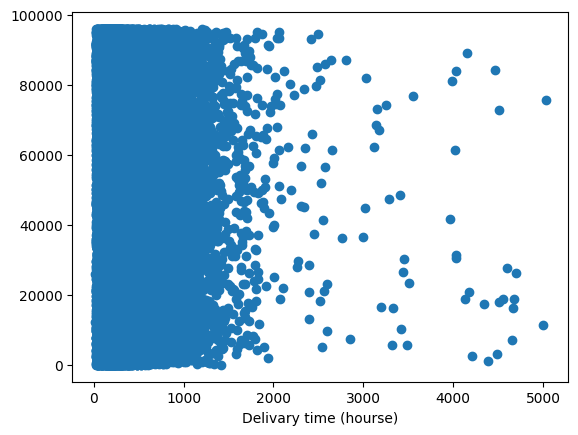

In [26]:
plt.scatter(x = df_train_data['delivery_duration_hours'],y = [i for i in range(0,95994)]);
plt.xlabel('Delivary time (hourse)');

(array([7.1680e+04, 1.6107e+04, 6.4710e+03, 1.6590e+03, 7.3000e+01,
        0.0000e+00, 3.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        1.0000e+00]),
 array([   0.        ,  788.90909091, 1577.81818182, 2366.72727273,
        3155.63636364, 3944.54545455, 4733.45454545, 5522.36363636,
        6311.27272727, 7100.18181818, 7889.09090909, 8678.        ]),
 <BarContainer object of 11 artists>)

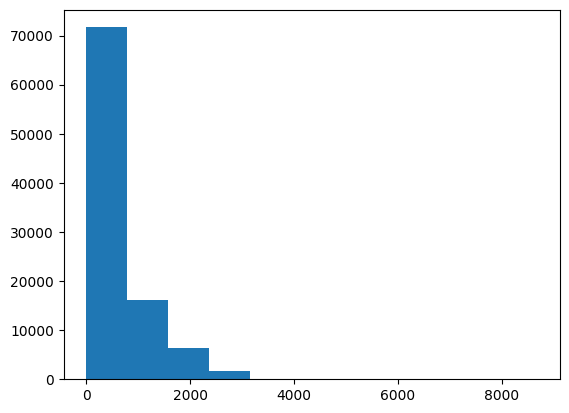

In [27]:
plt.hist(df_train_data['min_distance'],bins=11)

In [28]:
df_train_data[df_train_data['min_distance'] <1]

,delivery_duration_hours,purchase_dayofweek,ordered_time,order_count,min_distance,max_distance,avg_distance,distance_std,total_price,total_freight
order_id,,,,,,,,,,
065102a3bb506a1010c90b7a4f2700b2,26.811111,4,2018-03-02 11:34:37,1,0.0,0.0,0.0,0.0,149.00,15.55
2027c60e9786b0dbc84f5849a80976d8,189.210278,0,2018-08-13 17:23:09,1,0.0,0.0,0.0,0.0,99.99,23.44
3cfcc0ca272d41bdfa5d2ec747019f73,201.612778,2,2018-04-04 09:19:56,1,0.0,0.0,0.0,0.0,379.90,11.57
3d7d0dcc28a6dfb5464b9b43e751e45f,144.038333,2,2017-08-09 21:42:31,1,0.0,0.0,0.0,0.0,499.99,18.57
42a64eac09d0a6be5a307753093d45e8,34.189722,2,2017-10-25 08:53:51,1,0.0,0.0,0.0,0.0,99.99,12.15
4d5e865e4b64c8b33f8a81fd14731344,71.679722,4,2018-04-20 14:54:15,1,0.0,0.0,0.0,0.0,52.99,9.26
55d31aada518f8198b01470b36eda8f2,122.004722,0,2018-05-14 10:07:16,1,0.0,0.0,0.0,0.0,229.99,8.47
6a87a0371f263aa8c1779c2c115c1427,68.978333,5,2017-11-25 15:51:01,1,0.0,0.0,0.0,0.0,74.82,8.27
7c8582fc7ce51a091fe83cb5efa4e84e,127.433889,4,2018-01-12 14:57:31,1,0.0,0.0,0.0,0.0,13.88,7.78


Text(0, 0.5, 'Delivery time (Hours)')

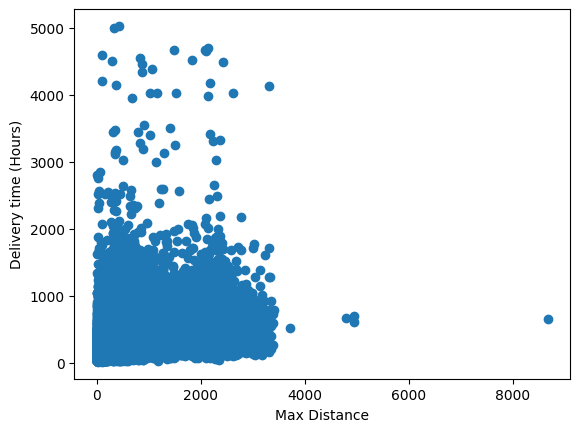

In [29]:
plt.scatter( df_train_data['max_distance'],   df_train_data['delivery_duration_hours'])
plt.xlabel('Max Distance')
plt.ylabel('Delivery time (Hours)')

In [30]:
df_train_data['is_weekend'] =  np.where((df_train_data['purchase_dayofweek'] == 5 ) | (df_train_data['purchase_dayofweek'] == 6),1,0)

In [31]:
df_train_data.drop(columns=('purchase_dayofweek'),inplace=True)

### removing outliers 

In [32]:
outlier_proof = df_train_data.copy()

In [33]:
outlier_proof = outlier_proof[outlier_proof['max_distance']<4000]
outlier_proof = outlier_proof[outlier_proof['delivery_duration_hours']<3500]


In [34]:
outlier_proof.describe()

,delivery_duration_hours,ordered_time,order_count,min_distance,max_distance,avg_distance,distance_std,total_price,total_freight,is_weekend
count,95964.000000,95964,95964.000000,95964.000000,95964.000000,95964.000000,95964.000000,95964.000000,95964.000000,95964.000000
mean,300.072129,2018-01-02 00:51:38.056646,1.038525,598.953899,601.617773,600.276716,1.825288,128.534497,22.776354,0.230003
min,12.801944,2016-09-15 12:16:38,1.000000,0.000000,0.000000,0.000000,0.000000,0.850000,0.000000,0.000000
25%,162.166458,2017-09-14 09:43:54,1.000000,182.000000,188.000000,187.000000,0.000000,43.200000,13.830000,0.000000
50%,245.007778,2018-01-20 20:50:54,1.000000,432.000000,435.500000,434.000000,0.000000,79.900000,17.160000,0.000000
75%,376.672639,2018-05-05 20:37:56,1.000000,796.000000,800.000000,797.000000,0.000000,144.000000,24.000000,0.000000
max,3482.907500,2018-08-29 15:00:37,8.000000,3710.000000,3710.000000,3710.000000,1652.508548,6735.000000,1794.960000,1.000000
std,219.220331,NaN,0.228046,592.115979,592.513501,592.014296,26.188408,192.657124,21.582292,0.420837


In [35]:
outlier_proof = outlier_proof[outlier_proof['total_price']<1500]
outlier_proof = outlier_proof[outlier_proof['min_distance']>10]


In [36]:

# 
outlier_proof.to_csv(os.path.join('..','data','processed','trained_data.csv'),index=False)

In [37]:


df_train_data.to_csv(os.path.join('..','data','processed','trained_data.csv'),index=False)